In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn import datasets,metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
cancer=datasets.load_breast_cancer()

In [4]:
cancer.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
print(cancer.feature_names)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [6]:
X=cancer.data
y=cancer.target
X.shape,y.shape
#{0:malignant, 1:benign}

((569, 30), (569,))

In [7]:
sum(y) #this show the 1 benign cases

np.int64(357)

In [8]:
len(y)-sum(y) #this show the 0 malignant cases

np.int64(212)

In [9]:
print("1 benign:",sum(y),"|","0 malignant:",len(y)-sum(y))

1 benign: 357 | 0 malignant: 212


([<matplotlib.axis.XTick at 0x7ff1df5c0800>,
 [Text(0, 0, 'malignant'), Text(1, 0, 'benign')])

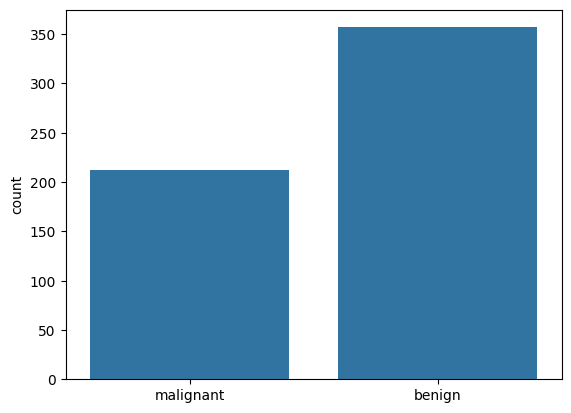

In [10]:
sns.countplot(x=y)
plt.xticks(np.arange(2),cancer.target_names)

In [11]:
df=pd.DataFrame(X,columns=cancer.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


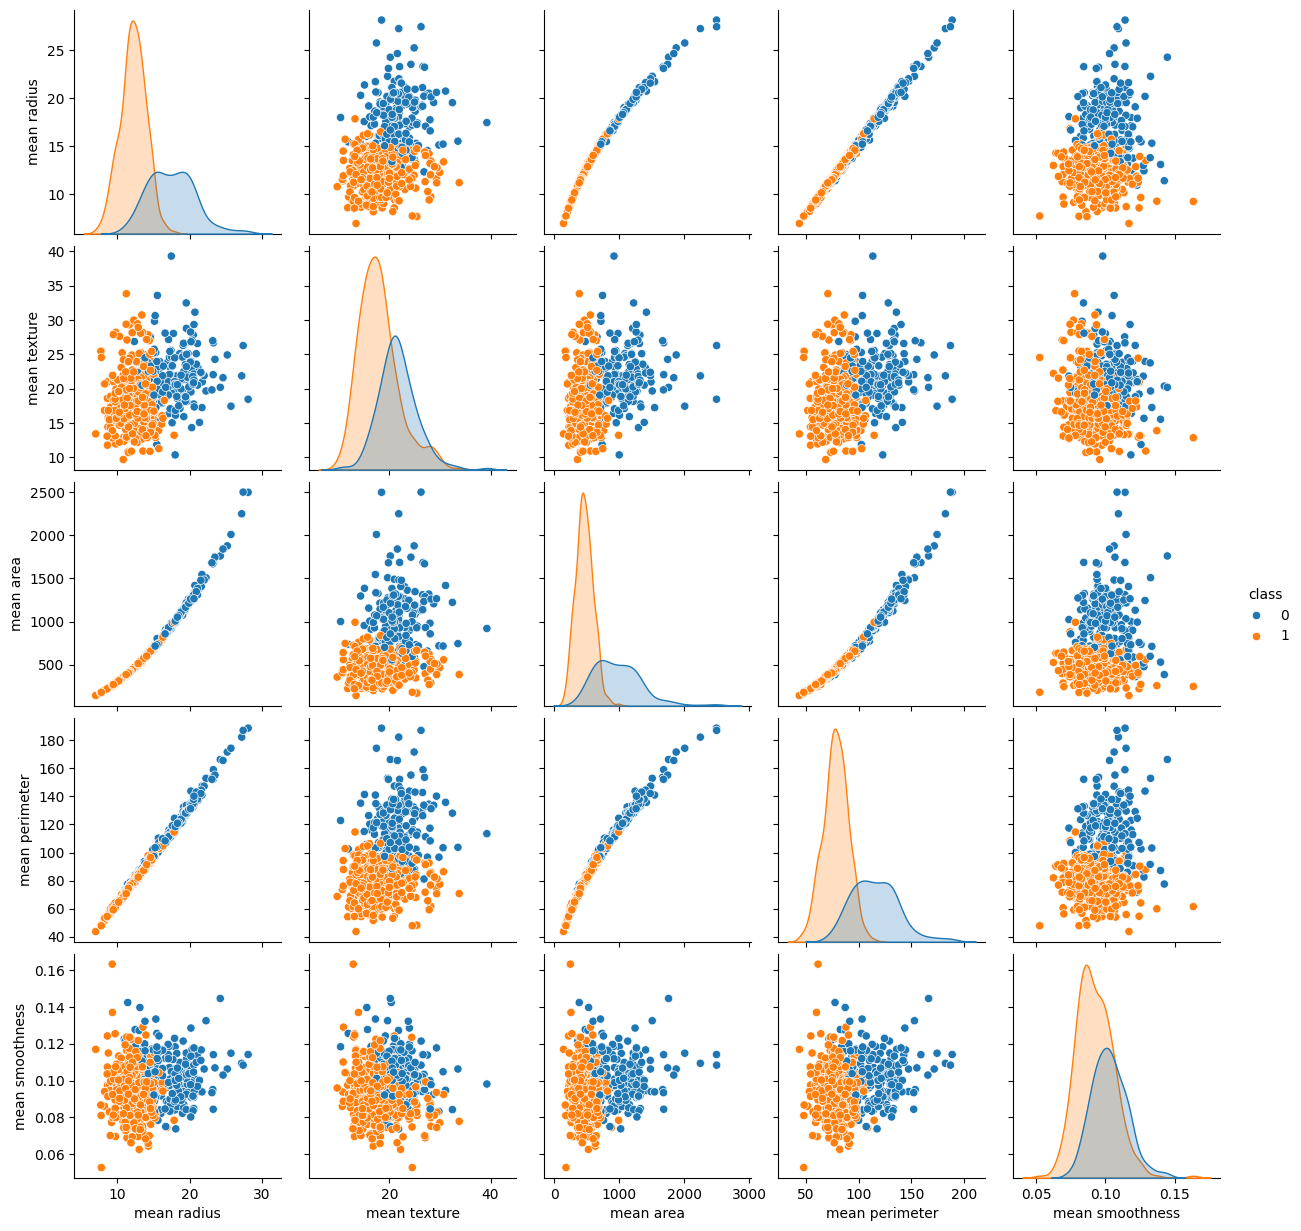

In [12]:
df['class']=cancer.target #y
sns.pairplot(df,hue='class',vars=['mean radius','mean texture',"mean area",'mean perimeter','mean smoothness'])

## Train-Test Split & Feature Scaling

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (455, 30) Test shape: (114, 30)


In [14]:
# SVM is distance-based, so features MUST be scaled first
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline SVM Model (Linear Kernel)

In [15]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
print("Linear kernel accuracy:", metrics.accuracy_score(y_test, y_pred_linear))

Linear kernel accuracy: 0.9736842105263158


## Model Evaluation

              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



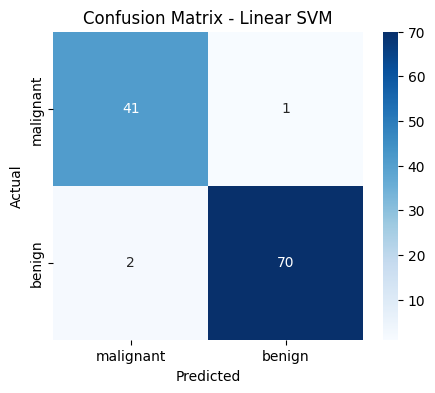

In [16]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred_linear)
print(classification_report(y_test, y_pred_linear, target_names=cancer.target_names))

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear SVM')
plt.show()

## Comparing Different Kernels

In [17]:
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
results = {}

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = metrics.accuracy_score(y_test, preds)
    results[k] = acc
    print(f"{k:>8} kernel accuracy: {acc:.4f}")

  linear kernel accuracy: 0.9737
     rbf kernel accuracy: 0.9825
    poly kernel accuracy: 0.9123
 sigmoid kernel accuracy: 0.9298


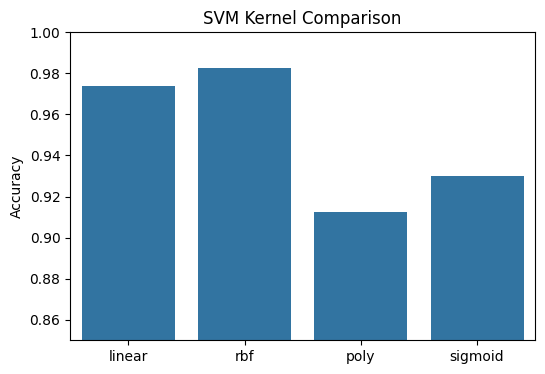

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylim(0.85, 1.0)
plt.ylabel('Accuracy')
plt.title('SVM Kernel Comparison')
plt.show()

## Hyperparameter Tuning with GridSearchCV

In [19]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 0.01, 0.001],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV accuracy: 0.9802197802197803


## Final Model (Best Estimator)

Test accuracy (tuned model): 0.9824561403508771

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



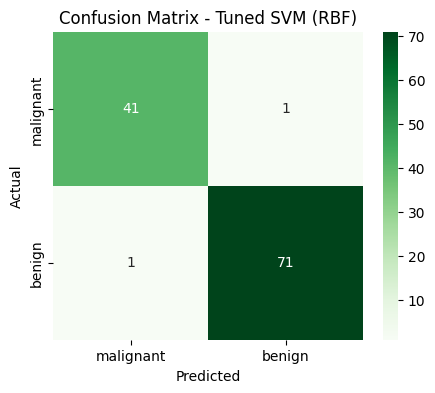

In [20]:
best_svm = grid.best_estimator_
y_pred_best = best_svm.predict(X_test_scaled)

print("Test accuracy (tuned model):", metrics.accuracy_score(y_test, y_pred_best))
print()
print(classification_report(y_test, y_pred_best, target_names=cancer.target_names))

cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Tuned SVM (RBF)')
plt.show()

## ROC Curve & AUC

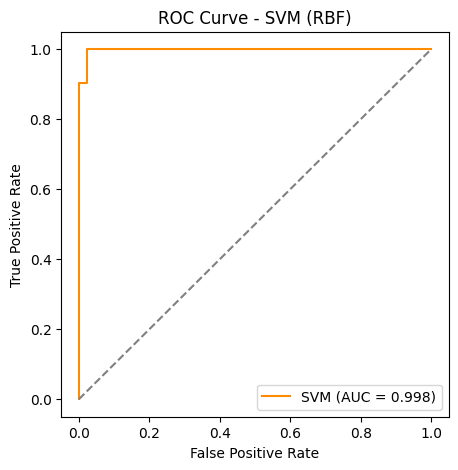

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# probability estimates need probability=True
svm_prob = SVC(kernel='rbf', C=grid.best_params_['C'], gamma=grid.best_params_['gamma'],
               probability=True, random_state=42)
svm_prob.fit(X_train_scaled, y_train)
y_proba = svm_prob.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'SVM (AUC = {auc_score:.3f})', color='darkorange')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM (RBF)')
plt.legend()
plt.show()

## Summary

- Dataset: Breast Cancer Wisconsin (569 samples, 30 features, binary target: malignant / benign).
- Features were standardized with `StandardScaler` since SVM is distance-based.
- Compared 4 kernels (linear, rbf, poly, sigmoid) — RBF/linear typically perform best on this dataset.
- Tuned `C` and `gamma` for the RBF kernel using `GridSearchCV` (5-fold CV).
- Evaluated the final model with accuracy, precision/recall/F1, confusion matrix, and ROC-AUC.